# miDGD — Training from Scratch

This notebook trains a minimal DGD model on the TCGA dataset stored in `data/`.
The model jointly models mRNA and miRNA expression using a shared decoder with
modality-specific Negative Binomial output heads and a Gaussian Mixture Model
prior on the latent space.

## 1. Imports

In [1]:
import os
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from base.utils.helpers import set_seed, get_activation
from base.dgd.nn import NB_Module
from base.dgd.DGD import DGD
from base.model.decoder import Decoder
from base.data.combined import GeneExpressionDatasetCombined
from base.engine.train import train_midgd

## 2. Seed and Device

In [2]:
seed = 42
set_seed(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

num_workers = 4

Device: cpu


## 3. Load Data

We load the full TCGA mRNA/miRNA count matrices and the pre-split annotation
files (train / val / test) that live in `data/`.

In [6]:
datadir = "./data/"

df_mrna  = pd.read_table(datadir + "tcga_mrna.tsv",  sep="\t", index_col=0)
df_mirna = pd.read_table(datadir + "tcga_mirna.tsv", sep="\t", index_col=0)

anno_train = pd.read_table(datadir + "TCGA_train_anno.tsv", sep="\t", index_col=0)
anno_val   = pd.read_table(datadir + "TCGA_val_anno.tsv",   sep="\t", index_col=0)
anno_test  = pd.read_table(datadir + "TCGA_test_anno.tsv",  sep="\t", index_col=0)

print(f"mRNA matrix  : {df_mrna.shape}   (samples × genes)")
print(f"miRNA matrix : {df_mirna.shape}  (samples × miRNAs)")
print(f"Train split  : {anno_train.shape[0]} samples")
print(f"Val   split  : {anno_val.shape[0]} samples")
print(f"Test  split  : {anno_test.shape[0]} samples")

mRNA matrix  : (224, 18393)   (samples × genes)
miRNA matrix : (224, 755)  (samples × miRNAs)
Train split  : 96 samples
Val   split  : 64 samples
Test  split  : 64 samples


### 3a. Optionally subset to the most variable genes

Training on all ~18 k genes is slow. Setting `is_subset = True` keeps the
`n_top_genes` genes with the highest variance across training samples, which
is enough to get a working model quickly.

In [7]:
is_subset   = False
n_top_genes = 2000

if is_subset:
    train_expr = df_mrna.loc[anno_train.index]
    variances  = train_expr.var(axis=0)
    top_genes  = variances.nlargest(n_top_genes).index
    df_mrna    = df_mrna[top_genes]
    print(f"Subsetted mRNA to {n_top_genes} most variable genes.")

# Slice each split using the annotation index
train_mrna  = df_mrna.loc[anno_train.index]
val_mrna    = df_mrna.loc[anno_val.index]
test_mrna   = df_mrna.loc[anno_test.index]

train_mirna = df_mirna.loc[anno_train.index]
val_mirna   = df_mirna.loc[anno_val.index]
test_mirna  = df_mirna.loc[anno_test.index]

mrna_dim  = train_mrna.shape[1]
mirna_dim = train_mirna.shape[1]
print(f"mRNA features  : {mrna_dim}")
print(f"miRNA features : {mirna_dim}")

mRNA features  : 18393
miRNA features : 755


### 3b. Build datasets and data loaders

In [8]:
scaling_type = "sum"  # library-size normalisation used inside the NB loss
batch_size   = 128

train_dataset = GeneExpressionDatasetCombined(
    train_mrna, train_mirna, anno_train, scaling_type=scaling_type)
val_dataset = GeneExpressionDatasetCombined(
    val_mrna,   val_mirna,   anno_val,   scaling_type=scaling_type)
test_dataset = GeneExpressionDatasetCombined(
    test_mrna,  test_mirna,  anno_test,  scaling_type=scaling_type)

train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=batch_size, shuffle=True,  num_workers=num_workers)
validation_loader = torch.utils.data.DataLoader(
    val_dataset,   batch_size=batch_size, shuffle=False, num_workers=num_workers)
test_loader = torch.utils.data.DataLoader(
    test_dataset,  batch_size=batch_size, shuffle=False, num_workers=num_workers)

n_cancer_types = len(np.unique(train_dataset.label))
print(f"Cancer types   : {n_cancer_types}")
print(f"Train / Val / Test: {len(train_dataset)} / {len(val_dataset)} / {len(test_dataset)}")

Cancer types   : 32
Train / Val / Test: 96 / 64 / 64


## 4. Model Setup

The DGD model consists of:
- A shared **decoder** (MLP) mapping latent representations → gene expression
- A modality-specific **NB output head** for each of mRNA and miRNA
- A **Gaussian Mixture Model** prior over the latent space

In [9]:
# --- Architecture hyperparameters ---
latent_dim  = 20
hidden_dims = [128, 128]
activation  = "leaky_relu"
r_init      = 2
output_scaling = "sum"

# --- GMM hyperparameters ---
gmm_radius      = 5.0
sd_mean         = 0.2
sd_mean_init    = sd_mean * gmm_radius / n_cancer_types
gmm_spec = {
    "mean_init":    (gmm_radius, 5.0),
    "sd_init":      (sd_mean_init, 1.0),
    "weight_alpha": 1,
}

# --- miRNA output head ---
mirna_fc = nn.Sequential(
    nn.Linear(hidden_dims[-1], 100),
    get_activation(activation),
    nn.Linear(100, 256),
    get_activation(activation),
    nn.Linear(256, mirna_dim),
)
output_mirna = NB_Module(mirna_fc, mirna_dim, r_init=r_init, scaling_type=output_scaling)
output_mirna.n_features = mirna_dim

# --- mRNA output head ---
mrna_fc = nn.Sequential(
    nn.Linear(hidden_dims[-1], 100),
    get_activation(activation),
    nn.Linear(100, 512),
    get_activation(activation),
    nn.Linear(512, mrna_dim),
)
output_mrna = NB_Module(mrna_fc, mrna_dim, r_init=r_init, scaling_type=output_scaling)
output_mrna.n_features = mrna_dim

# --- Decoder ---
decoder = Decoder(
    latent_dim, hidden_dims,
    output_module_mirna=output_mirna,
    output_module_mrna=output_mrna,
    activation=activation,
).to(device)

# --- DGD model ---
dgd = DGD(
    decoder=decoder,
    n_mix=n_cancer_types,
    rep_dim=latent_dim,
    gmm_spec=gmm_spec,
)

print(dgd)

DGD(
  (decoder): Decoder(
    (main): ModuleList(
      (0): Linear(in_features=20, out_features=128, bias=True)
      (1): LeakyReLU(negative_slope=0.01)
      (2): Linear(in_features=128, out_features=128, bias=True)
      (3): LeakyReLU(negative_slope=0.01)
    )
    (out_module_mirna): NB_Module(
      (fc): Sequential(
        (0): Linear(in_features=128, out_features=100, bias=True)
        (1): LeakyReLU(negative_slope=0.01)
        (2): Linear(in_features=100, out_features=256, bias=True)
        (3): LeakyReLU(negative_slope=0.01)
        (4): Linear(in_features=256, out_features=755, bias=True)
      )
    )
    (out_module_mrna): NB_Module(
      (fc): Sequential(
        (0): Linear(in_features=128, out_features=100, bias=True)
        (1): LeakyReLU(negative_slope=0.01)
        (2): Linear(in_features=100, out_features=512, bias=True)
        (3): LeakyReLU(negative_slope=0.01)
        (4): Linear(in_features=512, out_features=18393, bias=True)
      )
    )
  )
  (gmm): 

## 5. Training

Key notes:
- `weight_decay` must be a dict with keys `dec`, `rep`, `gmm`.
- `scheduler` must be a dict; pass `{'type': 'none'}` to skip LR scheduling.
- `subset` is an integer index into the miRNA feature axis used for monitoring metrics — must be in `[0, mirna_dim)`.
- `is_plot=False` disables per-epoch latent-space plots (set `True` to enable).

In [38]:
# Optimiser settings
learning_rates = {"dec": 1e-4, "rep": 1e-2, "gmm": 1e-2}
weight_decay   = {"dec": 1e-4, "rep": 0.,   "gmm": 0.}
betas          = (0.5, 0.7)

# Training schedule
nepochs        = 100          # increase for a full run (e.g. 500–1000)
reduction_type = "sum"
pr             = 10           # print metrics every N epochs

# Monitoring: single miRNA feature index used to track R² / correlation
subset         = 0            # must be < mirna_dim

# LR scheduler: 'none' | 'step' | 'exponential'
scheduler = {"type": "none"}

os.makedirs("models", exist_ok=True)

loss_tab = train_midgd(
    dgd, train_loader, validation_loader, device,
    learning_rates=learning_rates,
    weight_decay=weight_decay,
    betas=betas,
    nepochs=nepochs,
    pr=pr,
    plot=10,
    reduction_type=reduction_type,
    scaling_type=scaling_type,
    subset=subset,
    scheduler=scheduler,
    wandb_log=False,
    early_stopping=False,
    is_plot=False,
)

  1%|          | 1/100 [00:10<16:58, 10.29s/it]

0 train_loss: 24.73053240617123 train_loss_decoder: 22.531413346926435 train_recon_mirna: 13.509841508002207 train_recon_mrna: 9.021571838924228 train_gmm: 2.199119059244792 train_r2: -4197.95556640625 train_spearman: 0.1541144996881485 train_pearson: 0.05425570532679558
0 test_loss: 24.60807486604843 test_loss_decoder: 22.416610251180266 test_recon_mirna: 13.35156767384106 test_recon_mrna: 9.065042577339206 test_gmm: 2.1914646148681642 test_r2: -31844.908203125 test_spearman: 0.32367846369743347 test_pearson: 0.35026758909225464 delta_mirna: -0.1582738341611467


 11%|█         | 11/100 [00:42<05:03,  3.41s/it]

10 train_loss: 24.18531518447634 train_loss_decoder: 21.97808404433962 train_recon_mirna: 13.227807671081678 train_recon_mrna: 8.750276373257943 train_gmm: 2.207231140136719 train_r2: -3868.449462890625 train_spearman: 0.1574193835258484 train_pearson: 0.05834837630391121
10 test_loss: 24.128523951278922 test_loss_decoder: 21.90726502488732 test_recon_mirna: 13.084812189569536 test_recon_mrna: 8.822452835317783 test_gmm: 2.2212589263916014 test_r2: -29159.466796875 test_spearman: 0.32956770062446594 test_pearson: 0.3528471887111664 delta_mirna: -0.14299548151214125


 21%|██        | 21/100 [01:14<04:24,  3.35s/it]

...

 81%|████████  | 81/100 [04:22<01:00,  3.21s/it]

80 train_loss: 17.28360367059876 train_loss_decoder: 15.014178469182747 train_recon_mirna: 7.25672771799117 train_recon_mrna: 7.757450751191577 train_gmm: 2.2694252014160154 train_r2: -2.9752957820892334 train_spearman: 0.22686250507831573 train_pearson: 0.1431128978729248
80 test_loss: 17.831865225624956 test_loss_decoder: 15.483188353371538 test_recon_mirna: 7.498734349130794 test_recon_mrna: 7.984454004240744 test_gmm: 2.348676872253418 test_r2: -22.610769271850586 test_spearman: 0.2754647135734558 test_pearson: 0.26107990741729736 delta_mirna: 0.24200663113962406


 91%|█████████ | 91/100 [04:54<00:28,  3.14s/it]

90 train_loss: 16.80638362847681 train_loss_decoder: 14.539344647357016 train_recon_mirna: 6.813556757036424 train_recon_mrna: 7.725787890320593 train_gmm: 2.2670389811197915 train_r2: -2.1898324489593506 train_spearman: 0.22307580709457397 train_pearson: 0.14154192805290222
90 test_loss: 17.42811018656545 test_loss_decoder: 15.07743002604299 test_recon_mirna: 7.118327038493377 test_recon_mrna: 7.9591029875496115 test_gmm: 2.3506801605224608 test_r2: -18.25774383544922 test_spearman: 0.2861890494823456 test_pearson: 0.24423383176326752 delta_mirna: 0.3047702814569533


100%|██████████| 100/100 [05:25<00:00,  3.25s/it]


## 6. Save Model

In [39]:
torch.save(dgd,      "models/midgd_minimal.pt")
torch.save(loss_tab, "models/loss_minimal.pt")
pd.Series(df_mrna.columns).to_csv("models/mrna_genes.csv", index=False, header=False)
print("Saved model    → models/midgd_minimal.pt")
print("Saved losses   → models/loss_minimal.pt")
print("Saved gene list → models/mrna_genes.csv")

Saved model    → models/midgd_minimal.pt
Saved losses   → models/loss_minimal.pt
Saved gene list → models/mrna_genes.csv


In [40]:
len(np.array(loss_tab['train_loss']))

100

## 7. Loss Curves

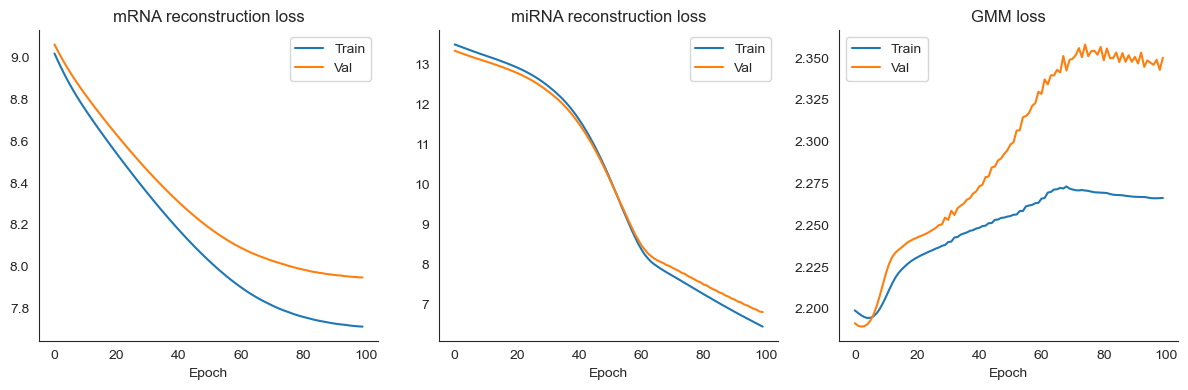

In [46]:
loss_column = ["epoch", "train_recon_mrna", "train_recon_mirna", "train_gmm",
               "test_recon_mrna", "test_recon_mirna", "test_gmm",
               "train_r2", "train_pearson", "train_spearman", "test_r2", "test_pearson", "test_spearman"]

loss_df = pd.DataFrame(loss_tab, columns=loss_column)

sns.set_style("white")
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].plot(loss_df["epoch"], loss_df["train_recon_mrna"],  label="Train")
axes[0].plot(loss_df["epoch"], loss_df["test_recon_mrna"],   label="Val")
axes[0].set_title("mRNA reconstruction loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(loss_df["epoch"], loss_df["train_recon_mirna"], label="Train")
axes[1].plot(loss_df["epoch"], loss_df["test_recon_mirna"],  label="Val")
axes[1].set_title("miRNA reconstruction loss")
axes[1].set_xlabel("Epoch")
axes[1].legend()

axes[2].plot(loss_df["epoch"], loss_df["train_gmm"], label="Train")
axes[2].plot(loss_df["epoch"], loss_df["test_gmm"],  label="Val")
axes[2].set_title("GMM loss")
axes[2].set_xlabel("Epoch")
axes[2].legend()

plt.tight_layout()
sns.despine()
plt.show()

## 8. Correlation Metrics

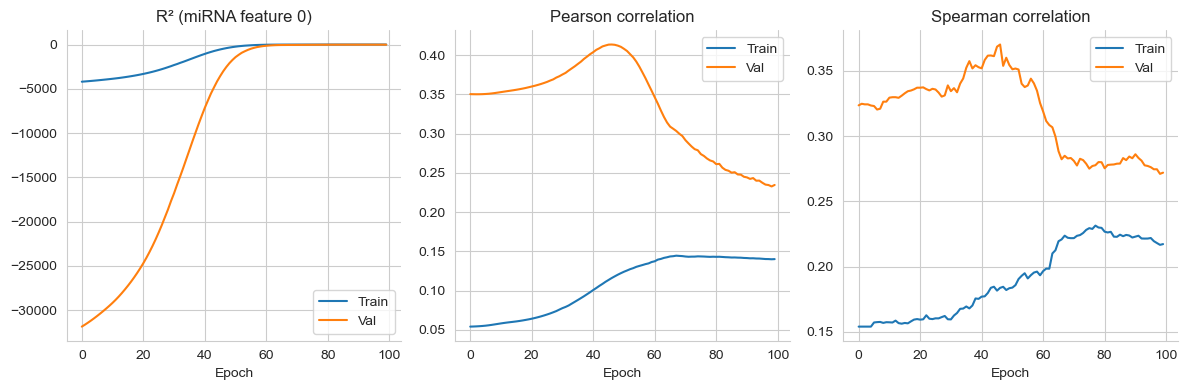

In [47]:
sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].plot(loss_df["epoch"], loss_df["train_r2"],      label="Train")
axes[0].plot(loss_df["epoch"], loss_df["test_r2"],       label="Val")
axes[0].set_title(f"R² (miRNA feature {subset})")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(loss_df["epoch"], loss_df["train_pearson"],  label="Train")
axes[1].plot(loss_df["epoch"], loss_df["test_pearson"],   label="Val")
axes[1].set_title("Pearson correlation")
axes[1].set_xlabel("Epoch")
axes[1].legend()

axes[2].plot(loss_df["epoch"], loss_df["train_spearman"], label="Train")
axes[2].plot(loss_df["epoch"], loss_df["test_spearman"],  label="Val")
axes[2].set_title("Spearman correlation")
axes[2].set_xlabel("Epoch")
axes[2].legend()

plt.tight_layout()
sns.despine()
plt.show()